# Question 2 - Classement par le modèle Bradley-Terry

compare-ia vote
Modèle de Bradley-Terry

## 0. Mise en place et exploration des données préliminaires

In [1]:
import pandas as pd

df_votes = pd.read_parquet(r"C:\Users\Asturiel\Documents\Cours\CentraleSupelec_COURS\Third_Year\Challenge-etude_de_cas-creativite\data\compareia-votes\votes.parquet")
display(df_votes)

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,112580,2025-10-28 17:02:44.266579,gemini-2.5-flash,grok-4-fast,"[gemini-2.5-flash, grok-4-fast]",None,crée des cartes types dixit sur le thème des m...,1.0,None,None,...,False,False,False,False,False,False,None,None,False,False
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,0.0,None,None,...,False,False,False,True,False,False,None,None,True,False
2,56377,2025-04-28 08:47:19.683661,phi-4,llama-3.1-405b,"[llama-3.1-405b, phi-4]",None,créer un texte sur le degrés d'intégration des...,1.0,None,None,...,False,False,False,False,False,False,None,None,False,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,0.0,None,None,...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157127,173535,2026-03-12 19:47:37.701635,gpt-5-mini,gpt-oss-20b,"[gpt-5-mini, gpt-oss-20b]",None,Qu'est ce qu'une smartcity ?,1.0,None,None,...,False,False,False,False,False,False,None,None,False,False
157128,173537,2026-03-12 19:59:04.659959,EuroLLM-22B-Instruct-2512,glm-5,"[EuroLLM-22B-Instruct-2512, glm-5]",EuroLLM-22B-Instruct-2512,Bébé jusqu’à quel âge ?,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
157129,173538,2026-03-12 20:00:16.294953,gpt-5-nano,grok-4.1-fast,"[gpt-5-nano, grok-4.1-fast]",grok-4.1-fast,Qui est la plus belle femme du monde?,0.0,None,None,...,False,False,True,False,False,False,None,None,False,False
157130,173539,2026-03-12 20:10:44.000588,mistral-medium-2508,gpt-5-nano,"[gpt-5-nano, mistral-medium-2508]",mistral-medium-2508,Un article sur le statistique des migrants dep...,0.0,None,None,...,False,False,False,False,False,False,None,None,True,False


In [2]:
list(df_votes.columns)

['id',
 'timestamp',
 'model_a_name',
 'model_b_name',
 'model_pair_name',
 'chosen_model_name',
 'opening_msg',
 'both_equal',
 'conversation_a',
 'conversation_b',
 'conv_turns',
 'selected_category',
 'is_unedited_prompt',
 'conversation_pair_id',
 'session_hash',
 'visitor_id',
 'conv_comments_a',
 'conv_comments_b',
 'conv_useful_a',
 'conv_useful_b',
 'conv_creative_a',
 'conv_creative_b',
 'conv_clear_formatting_a',
 'conv_clear_formatting_b',
 'conv_incorrect_a',
 'conv_incorrect_b',
 'conv_superficial_a',
 'conv_superficial_b',
 'conv_instructions_not_followed_a',
 'conv_instructions_not_followed_b',
 'system_prompt_b',
 'system_prompt_a',
 'conv_complete_a',
 'conv_complete_b']

## 1. Classement global vs. classement créativité

### a. Classement global

In [3]:
df_votes_no_ex_aequo = df_votes[df_votes["both_equal"] == 0]
df_votes_no_ex_aequo.head()

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,0.0,None,None,...,False,False,False,True,False,False,None,None,True,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,0.0,None,None,...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False
5,67265,2025-05-23 06:22:03.471010,llama-3.3-70b,llama-4-scout,"[llama-3.3-70b, llama-4-scout]",llama-3.3-70b,le sport le plus pratiquer en 2025,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
6,69592,2025-05-30 18:58:52.668743,grok-3-mini-beta,qwen3-32b,"[grok-3-mini-beta, qwen3-32b]",grok-3-mini-beta,Lyon a été capitale pendant quelques années au...,0.0,None,None,...,False,True,False,False,False,False,None,None,False,False


In [4]:
df_votes_no_ex_aequo["model_pair_name"] = df_votes_no_ex_aequo["model_pair_name"].apply(frozenset)
#frozenset est hashable, contrairement à set, ce qui permet de l'utiliser comme clé dans un dictionnaire 
# ou de le stocker dans un DataFrame. En utilisant frozenset, nous pouvons regrouper les votes par paire 
# de modèles sans se soucier de l'ordre des modèles dans la paire.
n_unique = df_votes_no_ex_aequo["model_pair_name"].nunique()

print(f"Nombre de paires de modèles uniques : {n_unique} \n")

Nombre de paires de modèles uniques : 2646 



C:\Users\Asturiel\AppData\Local\Temp\ipykernel_11212\948245798.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_votes_no_ex_aequo["model_pair_name"] = df_votes_no_ex_aequo["model_pair_name"].apply(frozenset)


In [5]:
df_votes_no_ex_aequo

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"(gemma-3-4b, c4ai-command-r-08-2024)",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,0.0,None,None,...,False,False,False,True,False,False,None,None,True,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"(phi-4, gemma-3-27b)",gemma-3-27b,Coucou,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"(chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,0.0,None,None,...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False
5,67265,2025-05-23 06:22:03.471010,llama-3.3-70b,llama-4-scout,"(llama-4-scout, llama-3.3-70b)",llama-3.3-70b,le sport le plus pratiquer en 2025,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
6,69592,2025-05-30 18:58:52.668743,grok-3-mini-beta,qwen3-32b,"(grok-3-mini-beta, qwen3-32b)",grok-3-mini-beta,Lyon a été capitale pendant quelques années au...,0.0,None,None,...,False,True,False,False,False,False,None,None,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157121,173528,2026-03-12 19:00:09.156248,claude-4-5-sonnet,minimax-m2.5,"(claude-4-5-sonnet, minimax-m2.5)",claude-4-5-sonnet,Donne moi une idée,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
157128,173537,2026-03-12 19:59:04.659959,EuroLLM-22B-Instruct-2512,glm-5,"(EuroLLM-22B-Instruct-2512, glm-5)",EuroLLM-22B-Instruct-2512,Bébé jusqu’à quel âge ?,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
157129,173538,2026-03-12 20:00:16.294953,gpt-5-nano,grok-4.1-fast,"(grok-4.1-fast, gpt-5-nano)",grok-4.1-fast,Qui est la plus belle femme du monde?,0.0,None,None,...,False,False,True,False,False,False,None,None,False,False
157130,173539,2026-03-12 20:10:44.000588,mistral-medium-2508,gpt-5-nano,"(mistral-medium-2508, gpt-5-nano)",mistral-medium-2508,Un article sur le statistique des migrants dep...,0.0,None,None,...,False,False,False,False,False,False,None,None,True,False


### b. Construction de la matrice de gains W[i,j]

In [6]:
import numpy as np
import pandas as pd

def build_win_matrix(df):
    """
    Construit la matrice de gains W à partir d'un DataFrame de votes.
    W[i, j] = nombre de fois que le modèle i a battu le modèle j.
    
    Paramètres
    ----------
    df : DataFrame contenant au minimum les colonnes
         model_a_name, model_b_name, chosen_model_name
    
    Retourne
    --------
    W     : np.ndarray (n x n), matrice de gains
    models: liste ordonnée des noms de modèles (index)
    """
    # --- 1. Identifier tous les modèles présents dans les comparaisons ---
    all_models = pd.unique(df[['model_a_name', 'model_b_name']].values.ravel())
    model_to_idx = {m: i for i, m in enumerate(all_models)}
    n = len(all_models)

    W = np.zeros((n, n), dtype=float)

    # --- 2. Remplir W : pour chaque vote, le gagnant marque +1 contre le perdant ---
    for _, row in df.iterrows():
        winner = row['chosen_model_name']
        a, b   = row['model_a_name'], row['model_b_name']
        loser  = b if winner == a else a
        if winner in model_to_idx and loser in model_to_idx:
            W[model_to_idx[winner], model_to_idx[loser]] += 1

    return W, list(all_models)


def filter_min_comparisons(W, models, N_min):
    """
    Supprime les modèles ayant participé à moins de N_min comparaisons.
    Le nombre de comparaisons d'un modèle i est sum(W[i,:]) + sum(W[:,i]).
    """
    total_games = W.sum(axis=1) + W.sum(axis=0)   # victoires + défaites
    mask = total_games >= N_min
    W_filtered = W[np.ix_(mask, mask)]
    models_filtered = [m for m, keep in zip(models, mask) if keep]
    return W_filtered, models_filtered


#### Choix empirique du seuil N
On visualise la distribution du nombre de comparaisons par modèle pour choisir N.

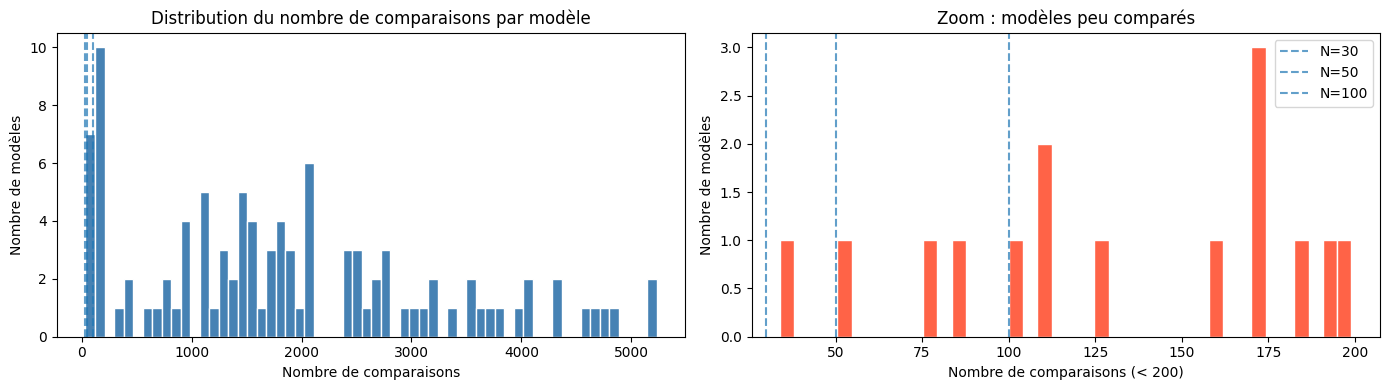

Total modèles : 101
  N ≥  30 → 101 modèles conservés
  N ≥  50 → 100 modèles conservés
  N ≥ 100 → 97 modèles conservés


In [7]:
import matplotlib.pyplot as plt

# Construction d'une matrice temporaire sur tout le dataset (sans seuil)
W_raw, models_raw = build_win_matrix(df_votes_no_ex_aequo)
total_games_raw = W_raw.sum(axis=1) + W_raw.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution complète
axes[0].hist(total_games_raw, bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Nombre de comparaisons")
axes[0].set_ylabel("Nombre de modèles")
axes[0].set_title("Distribution du nombre de comparaisons par modèle")

# Zoom sur la queue gauche (modèles peu représentés)
axes[1].hist(total_games_raw[total_games_raw < 200], bins=40, color='tomato', edgecolor='white')
axes[1].set_xlabel("Nombre de comparaisons (< 200)")
axes[1].set_ylabel("Nombre de modèles")
axes[1].set_title("Zoom : modèles peu comparés")

# Seuils candidats
for ax in axes:
    for thresh in [30, 50, 100]:
        ax.axvline(thresh, linestyle='--', alpha=0.7, label=f'N={thresh}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Résumé du nombre de modèles conservés pour chaque seuil
print(f"Total modèles : {len(models_raw)}")
for thresh in [30, 50, 100]:
    n_kept = (total_games_raw >= thresh).sum()
    print(f"  N ≥ {thresh:3d} → {n_kept} modèles conservés")


On choisit **N = 50** : ce seuil élimine les modèles trop peu comparés (estimations instables) 
tout en conservant un nombre suffisant de modèles pour un classement significatif.

### c. Estimation des paramètres β par MLE (algorithme de Zermelo)

In [8]:
def bradley_terry_mle(W, tol=1e-8, max_iter=10_000):
    """
    Estime les paramètres β du modèle Bradley-Terry par l'algorithme
    de Zermelo (itération de point fixe, aussi appelé MM-algorithm).

    Mise à jour à chaque itération :
        β_i  ←  w_i  /  Σ_j  n_ij / (β_i + β_j)

    où  w_i   = nombre total de victoires du modèle i
         n_ij  = W[i,j] + W[j,i]  (total de confrontations entre i et j)

    Les β sont normalisés à chaque pas (somme = 1) pour assurer l'unicité.

    Paramètres
    ----------
    W        : matrice de gains (n x n)
    tol      : critère de convergence (norme L1 entre deux itérations)
    max_iter : nombre maximum d'itérations

    Retourne
    --------
    beta : np.ndarray (n,), paramètres de force estimés
    """
    n = W.shape[0]

    # --- Nombre total de confrontations entre chaque paire (i, j) ---
    N = W + W.T   # n_ij = W[i,j] + W[j,i]

    # --- Nombre total de victoires de chaque modèle ---
    wins = W.sum(axis=1)   # w_i

    # --- Initialisation uniforme ---
    beta = np.ones(n) / n

    for iteration in range(max_iter):
        beta_old = beta.copy()

        # Dénominateur : Σ_j  n_ij / (β_i + β_j)  pour chaque i
        # On vectorise : denom[i] = Σ_j N[i,j] / (beta[i] + beta[j])
        beta_sum = beta[:, None] + beta[None, :]   # matrice (n x n)
        # Éviter division par zéro (paires jamais confrontées : N[i,j]=0)
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio = np.where(N > 0, N / beta_sum, 0.0)
        denom = ratio.sum(axis=1)

        # Mise à jour de β
        beta = np.where(denom > 0, wins / denom, 0.0)

        # Normalisation (unicité de la solution à une constante multiplicative près)
        total = beta.sum()
        if total > 0:
            beta /= total

        # Critère de convergence
        if np.abs(beta - beta_old).sum() < tol:
            print(f"Convergence atteinte à l'itération {iteration + 1}")
            break
    else:
        print(f"Attention : pas de convergence après {max_iter} itérations")

    return beta


def compute_ranking(W, models, N_min=50):
    """
    Pipeline complet :
      1. Filtrage des modèles sous le seuil
      2. Estimation des β par BT-MLE
      3. Retour d'un DataFrame classé par β décroissant
    """
    W_f, models_f = filter_min_comparisons(W, models, N_min)
    print(f"  → {len(models_f)} modèles retenus (N ≥ {N_min})")

    beta = bradley_terry_mle(W_f)

    df_rank = pd.DataFrame({'model': models_f, 'beta': beta})
    df_rank = df_rank.sort_values('beta', ascending=False).reset_index(drop=True)
    df_rank['rank'] = df_rank.index + 1
    return df_rank


### d. Classement global (tous les votes)

In [9]:
N_MIN = 50   # seuil empirique déterminé ci-dessus

print("=== Classement GLOBAL ===")
W_global, models_global = build_win_matrix(df_votes_no_ex_aequo)
df_rank_global = compute_ranking(W_global, models_global, N_min=N_MIN)

print("\nTop 15 modèles (classement global) :")
display(df_rank_global.head(15))


=== Classement GLOBAL ===
  → 100 modèles retenus (N ≥ 50)
Convergence atteinte à l'itération 142

Top 15 modèles (classement global) :


,model,beta,rank
0,gemini-3.1-flash-lite-preview,0.030507,1
1,mistral-medium-3.1,0.023187,2
2,mistral-large-2512,0.021961,3
3,gpt-5.4,0.021957,4
4,mistral-medium-2508,0.021591,5
5,gemini-3-flash-preview,0.021296,6
6,gemini-2.5-flash,0.020608,7
7,magistral-medium,0.018186,8
8,qwen3-max-2025-09-23,0.018066,9
9,gemini-3.1-pro-preview,0.017245,10


### e. Classement créativité (conversations créatives uniquement)

In [10]:
# Filtre : au moins l'une des deux conversations étiquetée comme créative
df_votes_creative = df_votes_no_ex_aequo[
    df_votes_no_ex_aequo['conv_creative_a'] | df_votes_no_ex_aequo['conv_creative_b']
].copy()

print(f"Votes créatifs : {len(df_votes_creative):,} / {len(df_votes_no_ex_aequo):,} "
      f"({100 * len(df_votes_creative) / len(df_votes_no_ex_aequo):.1f}%)")

print("\n=== Classement CRÉATIVITÉ ===")
W_creative, models_creative = build_win_matrix(df_votes_creative)
df_rank_creative = compute_ranking(W_creative, models_creative, N_min=N_MIN)

print("\nTop 15 modèles (classement créativité) :")
display(df_rank_creative.head(15))


Votes créatifs : 7,580 / 94,939 (8.0%)

=== Classement CRÉATIVITÉ ===
  → 75 modèles retenus (N ≥ 50)
Convergence atteinte à l'itération 202

Top 15 modèles (classement créativité) :


,model,beta,rank
0,mistral-medium-2508,0.044377,1
1,qwen3-max-2025-09-23,0.035538,2
2,mistral-large-2512,0.034789,3
3,gemini-3-pro-preview,0.029686,4
4,deepseek-chat-v3.1,0.029502,5
5,gemini-3-flash-preview,0.028515,6
6,DeepSeek-V3.2,0.027484,7
7,Qwen3-Coder-480B-A35B-Instruct,0.026628,8
8,gemini-2.5-flash,0.026526,9
9,gemini-2.0-flash,0.025271,10


### f. Comparaison des deux classements (Spearman ρ + scatter plot)

In [11]:
from scipy.stats import spearmanr

# --- Jointure sur les modèles présents dans LES DEUX classements ---
df_merged = df_rank_global[['model', 'rank']].rename(columns={'rank': 'rank_global'}).merge(
    df_rank_creative[['model', 'rank']].rename(columns={'rank': 'rank_creative'}),
    on='model'
)

print(f"Modèles communs aux deux classements : {len(df_merged)}")

# --- Corrélation de Spearman ---
rho, pval = spearmanr(df_merged['rank_global'], df_merged['rank_creative'])
print(f"Corrélation de Spearman ρ = {rho:.3f}  (p = {pval:.2e})")


Modèles communs aux deux classements : 75
Corrélation de Spearman ρ = 0.874  (p = 1.51e-24)


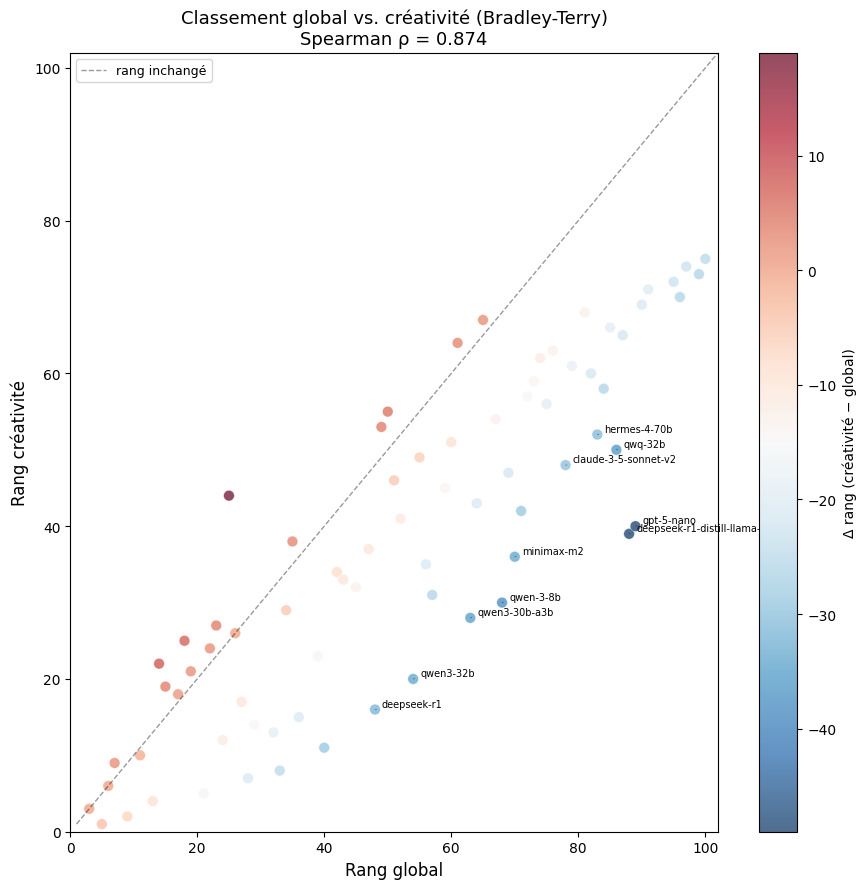


Modèles avec les plus grands écarts de classement :


,model,rank_global,rank_creative,rank_diff
0,deepseek-r1-distill-llama-70b,88,39,-49
1,gpt-5-nano,89,40,-49
2,qwen-3-8b,68,30,-38
3,qwq-32b,86,50,-36
4,qwen3-30b-a3b,63,28,-35
5,qwen3-32b,54,20,-34
6,minimax-m2,70,36,-34
7,deepseek-r1,48,16,-32
8,hermes-4-70b,83,52,-31
9,claude-3-5-sonnet-v2,78,48,-30


In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 9))

# Écart de rang (absolu) pour identifier les modèles qui bougent le plus
df_merged['rank_diff'] = df_merged['rank_creative'] - df_merged['rank_global']
df_merged['abs_diff']  = df_merged['rank_diff'].abs()

# Seuil pour annoter : top 10 des modèles avec le plus grand mouvement
threshold = df_merged['abs_diff'].nlargest(10).min()

# Scatter : couleur = direction du mouvement
scatter = ax.scatter(
    df_merged['rank_global'],
    df_merged['rank_creative'],
    c=df_merged['rank_diff'],        # positif = monte en créativité
    cmap='RdBu_r',
    s=60,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.4
)
plt.colorbar(scatter, ax=ax, label='Δ rang (créativité − global)')

# Diagonale de référence (rang inchangé)
lim = max(df_merged[['rank_global', 'rank_creative']].max()) + 2
ax.plot([1, lim], [1, lim], 'k--', lw=1, alpha=0.4, label='rang inchangé')

# Annotations des modèles qui bougent le plus
for _, row in df_merged[df_merged['abs_diff'] >= threshold].iterrows():
    ax.annotate(
        row['model'],
        xy=(row['rank_global'], row['rank_creative']),
        fontsize=7,
        xytext=(5, 2),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.5)
    )

ax.set_xlabel("Rang global", fontsize=12)
ax.set_ylabel("Rang créativité", fontsize=12)
ax.set_title(
    f"Classement global vs. créativité (Bradley-Terry)\nSpearman ρ = {rho:.3f}",
    fontsize=13
)
ax.legend(fontsize=9)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

# --- Tableau des modèles avec le plus grand écart ---
print("\nModèles avec les plus grands écarts de classement :")
display(
    df_merged.sort_values('abs_diff', ascending=False)
             .head(15)[['model', 'rank_global', 'rank_creative', 'rank_diff']]
             .reset_index(drop=True)
)


## 2. Transitivité stochastique et ex-aequo

La **transitivité stochastique forte** stipule que si P(i > j) ≥ 0.5 et P(j > k) ≥ 0.5,
alors P(i > k) ≥ max(P(i > j), P(j > k)).

On teste ici une forme plus faible (**transitivité stochastique simple**) :
si P(i > j) ≥ 0.5 et P(j > k) ≥ 0.5, alors P(i > k) ≥ 0.5.

On restreint l'analyse aux **20 modèles les plus comparés** pour maximiser
la densité des observations et la fiabilité des estimations de probabilité.

### a. Transitivité stochastique

Top 20 modèles les plus comparés :
   1. llama-3.3-70b (5232 comparaisons)
   2. gemma-3-4b (5206 comparaisons)
   3. phi-4 (4842 comparaisons)
   4. gemma-3-27b (4720 comparaisons)
   5. gemma-3-12b (4627 comparaisons)
   6. gemini-2.0-flash (4595 comparaisons)
   7. mistral-large-2411 (4332 comparaisons)
   8. llama-3.1-8b (4328 comparaisons)
   9. command-a (4042 comparaisons)
  10. ministral-8b-instruct-2410 (4022 comparaisons)
  11. llama-3.1-405b (3979 comparaisons)
  12. gpt-4.1-mini (3788 comparaisons)
  13. qwen2.5-coder-32b-instruct (3695 comparaisons)
  14. llama-4-scout (3631 comparaisons)
  15. claude-4-5-sonnet (3575 comparaisons)
  16. mistral-medium-2508 (3505 comparaisons)
  17. llama-3.1-nemotron-70b-instruct (3378 comparaisons)
  18. hermes-3-llama-3.1-405b (3225 comparaisons)
  19. gpt-4o-mini-2024-07-18 (3179 comparaisons)
  20. mistral-small-2506 (3123 comparaisons)

Triplets testables       : 884
Violations détectées     : 63
Taux de violation        : 7.1%

Exem

,i,j,k,P(i>j),P(j>k),P(i>k)
0,mistral-small-2506,llama-3.1-nemotron-70b-instruct,llama-3.1-405b,1.000,0.694,0.0
1,mistral-small-2506,gemma-3-27b,llama-3.1-405b,0.574,0.767,0.0
2,mistral-small-2506,phi-4,llama-3.1-405b,0.679,0.589,0.0
3,mistral-small-2506,gemma-3-4b,llama-3.1-405b,0.606,0.722,0.0
4,mistral-small-2506,gpt-4.1-mini,llama-3.1-405b,0.667,0.813,0.0
5,mistral-small-2506,llama-4-scout,llama-3.1-405b,0.662,0.841,0.0
6,mistral-small-2506,llama-3.3-70b,llama-3.1-405b,0.654,0.642,0.0
7,mistral-small-2506,llama-3.1-8b,llama-3.1-405b,0.723,0.562,0.0
8,mistral-small-2506,command-a,llama-3.1-405b,0.586,0.790,0.0
9,llama-3.1-nemotron-70b-instruct,llama-3.1-405b,mistral-small-2506,0.694,1.000,0.0


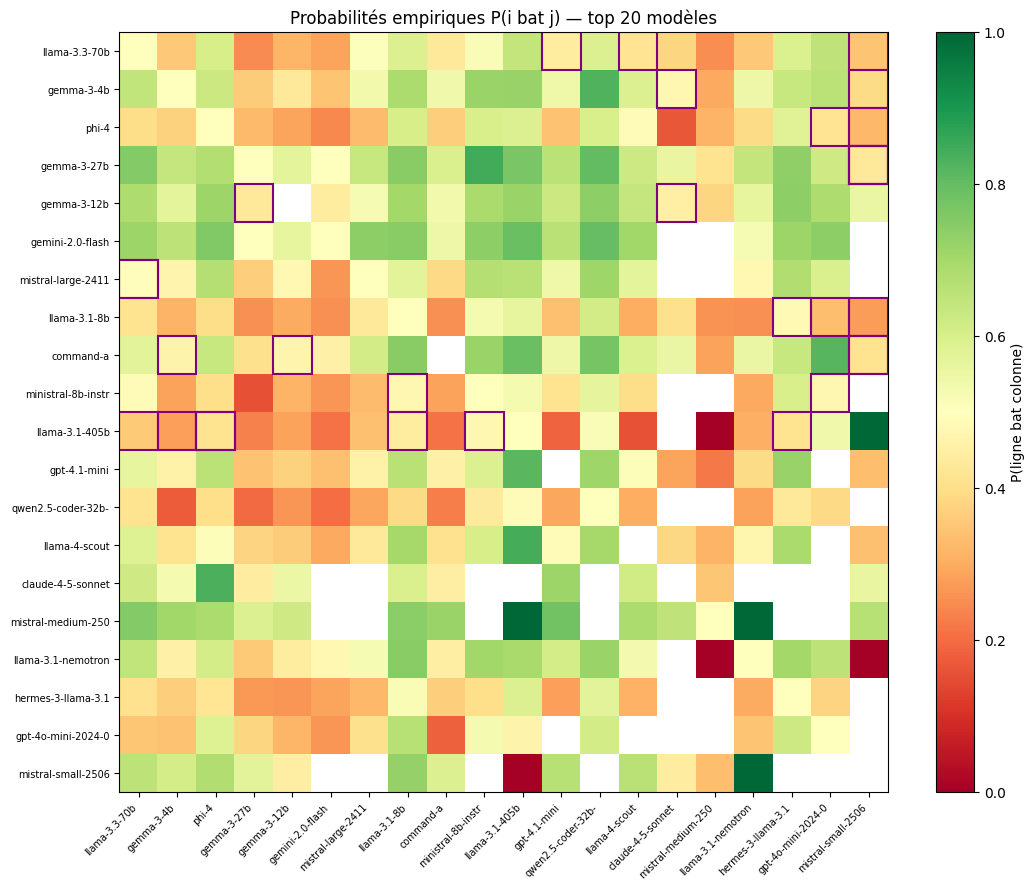

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import itertools

# ── 1. Identifier les 20 modèles les plus comparés ──────────────────────────
# On repart de la matrice globale déjà construite
total_games = W_global.sum(axis=1) + W_global.sum(axis=0)
top20_idx   = np.argsort(total_games)[::-1][:20]
top20_models = [models_global[i] for i in top20_idx] 

print("Top 20 modèles les plus comparés :")
for rank, (idx, name) in enumerate(zip(top20_idx, top20_models), 1):
    print(f"  {rank:2d}. {name} ({int(total_games[idx])} comparaisons)")

# ── 2. Sous-matrice W restreinte aux 20 modèles ──────────────────────────────
W_top20 = W_global[np.ix_(top20_idx, top20_idx)]
n20 = len(top20_models)

# ── 3. Estimer P(i bat j) empiriquement ─────────────────────────────────────
# P_emp[i,j] = W[i,j] / (W[i,j] + W[j,i])  si des duels existent, NaN sinon
N_pairs = W_top20 + W_top20.T
with np.errstate(invalid='ignore', divide='ignore'):
    P_emp = np.where(N_pairs > 0, W_top20 / N_pairs, np.nan)

# ── 4. Tester la transitivité stochastique simple ────────────────────────────
# Pour chaque triplet (i, j, k) avec P(i>j)>=0.5 et P(j>k)>=0.5,
# vérifier que P(i>k)>=0.5
violations = []
total_testable = 0

for i, j, k in itertools.permutations(range(n20), 3):
    p_ij = P_emp[i, j]
    p_jk = P_emp[j, k]
    p_ik = P_emp[i, k]

    # Triplet testable seulement si toutes les paires ont des observations
    if np.isnan(p_ij) or np.isnan(p_jk) or np.isnan(p_ik):
        continue

    if p_ij >= 0.5 and p_jk >= 0.5:
        total_testable += 1
        if p_ik < 0.5:   # violation !
            violations.append({
                'i': top20_models[i], 'j': top20_models[j], 'k': top20_models[k],
                'P(i>j)': round(p_ij, 3), 'P(j>k)': round(p_jk, 3), 'P(i>k)': round(p_ik, 3)
            })

df_violations = pd.DataFrame(violations)
taux = len(violations) / total_testable * 100 if total_testable > 0 else 0

print(f"\nTriplets testables       : {total_testable}")
print(f"Violations détectées     : {len(violations)}")
print(f"Taux de violation        : {taux:.1f}%")

if len(violations) > 0:
    print("\nExemples de violations (top 10 par écart sur P(i>k)) :")
    display(
        df_violations
        .sort_values('P(i>k)')
        .head(10)
        .reset_index(drop=True)
    )

# ── 5. Heatmap de P_emp ─────────────────────────────────────────────────────
# Noms abrégés pour lisibilité
short = [m[:18] for m in top20_models]

fig, ax = plt.subplots(figsize=(11, 9))
# Masque les cases NaN (jamais confrontés)
im = ax.imshow(P_emp, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='P(ligne bat colonne)')

ax.set_xticks(range(n20)); ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(n20)); ax.set_yticklabels(short, fontsize=7)
ax.set_title("Probabilités empiriques P(i bat j) — top 20 modèles", fontsize=12)

# Annoter les violations : encadrer la case P(i>k) en violet
for v in violations[:30]:   # limiter pour ne pas surcharger
    ii = top20_models.index(v['i'])
    kk = top20_models.index(v['k'])
    ax.add_patch(plt.Rectangle((kk-0.5, ii-0.5), 1, 1,
                                fill=False, edgecolor='purple', lw=1.5))

plt.tight_layout()
plt.show()


### b. Nombre minimum de comparaisons pour distinguer le rang 3 du rang 5

**Problème :** on veut savoir combien de duels directs entre le modèle classé 3ème
et le modèle classé 5ème sont nécessaires pour détecter leur différence avec :
- une puissance statistique de **80%** (probabilité de détecter une vraie différence)
- un seuil de significativité **α = 0.05** (probabilité d'erreur de type I)

On modélise chaque duel comme une épreuve de Bernoulli :
sous H₀, P(3 bat 5) = 0.5 (indistinguables) ;
sous H₁, P(3 bat 5) = β₃/(β₃+β₅) d'après les scores Bradley-Terry estimés.

Le test utilisé est un **test binomial unilatéral**.

Modèle rang 3 : 'mistral-large-2512'                      β = 0.021961
Modèle rang 5 : 'mistral-medium-2508'                     β = 0.021591
P(rang-3 bat rang-5) sous H₁ = 0.5043
  → l'effet à détecter est très faible

─── Résultat du test de puissance ───
α = 0.05,  puissance cible = 80%
Puissance 80% non atteinte dans la plage testée (p1 trop proche de 0.5)


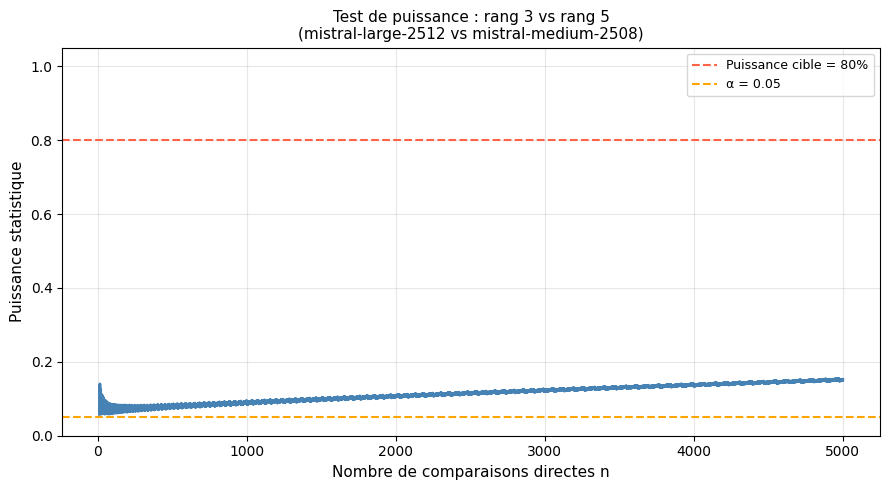

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Récupérer β₃ et β₅ du classement global ──────────────────────────────
# df_rank_global est trié par rang croissant (rang 1 = meilleur)
model_rank3 = df_rank_global.iloc[2]   # index 0-based → rang 3
model_rank5 = df_rank_global.iloc[4]   # index 0-based → rang 5

beta3 = model_rank3['beta']
beta5 = model_rank5['beta']
p1    = beta3 / (beta3 + beta5)        # probabilité que rang-3 batte rang-5 sous H₁

print(f"Modèle rang 3 : {model_rank3['model']!r:40s}  β = {beta3:.6f}")
print(f"Modèle rang 5 : {model_rank5['model']!r:40s}  β = {beta5:.6f}")
print(f"P(rang-3 bat rang-5) sous H₁ = {p1:.4f}")
print(f"  → l'effet à détecter est {'très faible' if p1 < 0.55 else 'modéré' if p1 < 0.65 else 'fort'}")

# ── 2. Calcul de la puissance pour un n donné ────────────────────────────────
# Test binomial unilatéral (H₁ : p > 0.5)
# La région de rejet est  X >= c  où c est le plus petit entier
# tel que P(X >= c | p=0.5) <= alpha
#
# Puissance = P(X >= c | p=p1)

alpha = 0.05
target_power = 0.80

def compute_power(n, p0=0.5, p1=p1, alpha=alpha):
    """Puissance du test binomial unilatéral pour n duels."""
    # Seuil critique : plus petit c tel que P(X>=c | H0) <= alpha
    # Équivalent : c = quantile(1-alpha) de Binom(n, p0) + 1
    c = stats.binom.ppf(1 - alpha, n, p0)  # ppf donne le plus grand k tel que CDF(k)<=1-alpha
    # Puissance = P(X >= c | p1)
    power = 1 - stats.binom.cdf(c - 1, n, p1)
    return power

# ── 3. Recherche du n minimal par balayage ───────────────────────────────────
n_values = np.arange(10, 5001)
powers   = [compute_power(n) for n in n_values]

# n minimal où la puissance atteint 80%
n_min = None
for n, pw in zip(n_values, powers):
    if pw >= target_power:
        n_min = n
        break

print("\n─── Résultat du test de puissance ───")
print(f"α = {alpha},  puissance cible = {target_power*100:.0f}%")
if n_min:
    print(f"Nombre minimum de comparaisons : n = {n_min}")
    print(f"Puissance atteinte à n={n_min}     : {compute_power(n_min)*100:.1f}%")
else:
    print("Puissance 80% non atteinte dans la plage testée (p1 trop proche de 0.5)")

# ── 4. Courbe puissance en fonction de n ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_values, powers, color='steelblue', lw=2)
ax.axhline(target_power, color='tomato', ls='--', lw=1.5, label=f'Puissance cible = {target_power*100:.0f}%')
ax.axhline(alpha,        color='orange',  ls='--', lw=1.5, label=f'α = {alpha}')

if n_min:
    ax.axvline(n_min, color='green', ls=':', lw=2, label=f'n minimum = {n_min}')
    ax.scatter([n_min], [compute_power(n_min)], color='green', zorder=5, s=80)

ax.set_xlabel("Nombre de comparaisons directes n", fontsize=11)
ax.set_ylabel("Puissance statistique", fontsize=11)
ax.set_title(
    f"Test de puissance : rang 3 vs rang 5\n"
    f"({model_rank3['model']} vs {model_rank5['model']})",
    fontsize=11
)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**P(rang-3 bat rang-5) = 0.5043**. L'effet à détecter est minuscule — les deux modèles ont des β quasi-identiques (0.021961 vs 0.021591, soit 1.7% d'écart). Pour détecter une telle différence avec 80% de puissance, il faudrait des dizaines de milliers de duels directs entre ces deux modèles spécifiques, ce que le dataset ne peut pas fournir.
Ce que ça dit sur le classement : la différence de rang entre le 3ème et le 5ème modèle n'est pas statistiquement significative.

### c. Extension Davidson — intégration des ex-æquo

Le modèle Bradley-Terry classique ignore les ex-æquo. L'extension de Davidson (1970)
les incorpore en ajoutant un paramètre **ν > 0** ("tie parameter") qui capte
la tendance générale à l'ex-æquo.

Les probabilités deviennent :

```
P(i bat j)   = βᵢ / (βᵢ + ν·√(βᵢβⱼ) + βⱼ)
P(ex-æquo)   = ν·√(βᵢβⱼ) / (βᵢ + ν·√(βᵢβⱼ) + βⱼ)
P(j bat i)   = βⱼ / (βᵢ + ν·√(βᵢβⱼ) + βⱼ)
```

Quand ν → 0, on retrouve le modèle BT classique.
On estime β et ν conjointement par un algorithme MM (itération de point fixe).

In [15]:
import numpy as np
import pandas as pd

def build_davidson_matrices(df_all):
    """
    Construit les matrices nécessaires à l'estimation Davidson
    à partir du DataFrame COMPLET (avec ex-æquo).

    Retourne
    --------
    W  : matrice de gains strictes   W[i,j] = victoires de i sur j
    T  : matrice d'ex-æquo           T[i,j] = ex-æquo entre i et j (symétrique)
    models : liste des noms de modèles
    """
    all_models = pd.unique(df_all[['model_a_name', 'model_b_name']].values.ravel())
    model_to_idx = {m: i for i, m in enumerate(all_models)}
    n = len(all_models)

    W = np.zeros((n, n), dtype=float)
    T = np.zeros((n, n), dtype=float)

    for _, row in df_all.iterrows():
        a = row['model_a_name']
        b = row['model_b_name']
        if a not in model_to_idx or b not in model_to_idx:
            continue
        ia, ib = model_to_idx[a], model_to_idx[b]

        if row['both_equal'] == 1:          # ex-æquo
            T[ia, ib] += 1
            T[ib, ia] += 1
        else:                               # victoire nette
            winner = row['chosen_model_name']
            loser  = b if winner == a else a
            if winner in model_to_idx and loser in model_to_idx:
                W[model_to_idx[winner], model_to_idx[loser]] += 1

    return W, T, list(all_models)


def davidson_mle(W, T, tol=1e-8, max_iter=10_000):
    """
    Estime les paramètres (β, ν) du modèle Davidson par algorithme MM.

    Mises à jour :
      ν    ←  Σᵢ<ⱼ T[i,j]  /  Σᵢ<ⱼ T[i,j] · √(βᵢβⱼ) / (βᵢ + ν√(βᵢβⱼ) + βⱼ)
      βᵢ   ←  (wᵢ + tᵢ/2)  /  Σⱼ≠ᵢ (nᵢⱼ + tᵢⱼ/2) / (βᵢ + ν√(βᵢβⱼ) + βⱼ)

    où tᵢ = Σⱼ T[i,j] (total des ex-æquo de i)
    """
    n = W.shape[0]
    beta = np.ones(n) / n
    nu   = 1.0           # initialisation du paramètre d'ex-æquo

    # Victoires totales et ex-æquo totaux par modèle
    wins  = W.sum(axis=1)
    ties  = T.sum(axis=1) / 2   # T est symétrique, chaque ex-æquo compté deux fois

    for iteration in range(max_iter):
        beta_old = beta.copy()
        nu_old   = nu

        # Terme commun : dénominateur D[i,j] = βᵢ + ν√(βᵢβⱼ) + βⱼ
        sqrt_prod = np.sqrt(np.outer(beta, beta))          # √(βᵢβⱼ)
        D = beta[:, None] + nu * sqrt_prod + beta[None, :] # D[i,j]

        # ── Mise à jour de ν ────────────────────────────────────────────────
        # Seulement sur les paires i < j avec des ex-æquo
        mask_upper = np.triu(T > 0, k=1)
        num_nu   = T[mask_upper].sum()
        with np.errstate(invalid='ignore', divide='ignore'):
            denom_nu = np.where(
                mask_upper & (D > 0),
                T * sqrt_prod / D,
                0.0
            ).sum()
        nu = num_nu / denom_nu if denom_nu > 0 else nu

        # ── Mise à jour de β ────────────────────────────────────────────────
        # Numérateur : wᵢ + tᵢ/2  (tᵢ/2 car chaque ex-æquo vaut 0.5 point)
        numer_beta = wins + ties

        # Dénominateur : Σⱼ (nᵢⱼ + tᵢⱼ/2) / D[i,j]
        N_ij = W + W.T           # comparaisons nettes
        contrib = N_ij + T / 2   # pondéré ex-æquo
        with np.errstate(invalid='ignore', divide='ignore'):
            denom_beta = np.where(D > 0, contrib / D, 0.0).sum(axis=1)
        beta = np.where(denom_beta > 0, numer_beta / denom_beta, 0.0)

        # Normalisation
        s = beta.sum()
        if s > 0:
            beta /= s

        # Convergence
        if np.abs(beta - beta_old).sum() + abs(nu - nu_old) < tol:
            print(f"  Davidson : convergence à l'itération {iteration + 1}  (ν = {nu:.4f})")
            break
    else:
        print(f"  Davidson : pas de convergence après {max_iter} itérations")

    return beta, nu


# ── Estimation Davidson ──────────────────────────────────────────────────────
print("Construction des matrices Davidson (votes complets + ex-æquo)...")
W_dav, T_dav, models_dav = build_davidson_matrices(df_votes)

# Filtrage N_MIN
total_dav = W_dav.sum(axis=1) + W_dav.sum(axis=0) + T_dav.sum(axis=1) / 2
mask_dav  = total_dav >= N_MIN
W_dav_f   = W_dav[np.ix_(mask_dav, mask_dav)]
T_dav_f   = T_dav[np.ix_(mask_dav, mask_dav)]
models_dav_f = [m for m, keep in zip(models_dav, mask_dav) if keep]
print(f"  → {len(models_dav_f)} modèles retenus (N ≥ {N_MIN})")

print("Estimation Davidson...")
beta_dav, nu_est = davidson_mle(W_dav_f, T_dav_f)

df_rank_davidson = pd.DataFrame({'model': models_dav_f, 'beta_davidson': beta_dav})
df_rank_davidson = df_rank_davidson.sort_values('beta_davidson', ascending=False).reset_index(drop=True)
df_rank_davidson['rank_davidson'] = df_rank_davidson.index + 1

print(f"\nParamètre d'ex-æquo estimé : ν = {nu_est:.4f}")
print("Top 15 (Davidson) :")
display(df_rank_davidson.head(15))


Construction des matrices Davidson (votes complets + ex-æquo)...
  → 105 modèles retenus (N ≥ 50)
Estimation Davidson...
  Davidson : pas de convergence après 10000 itérations

Paramètre d'ex-æquo estimé : ν = 20780.5026
Top 15 (Davidson) :


,model,beta_davidson,rank_davidson
0,gemini-3.1-flash-lite-preview,0.024640,1
1,gpt-5.4,0.022841,2
2,mistral-large-2512,0.021348,3
3,gemini-3-flash-preview,0.020195,4
4,gemini-3.1-pro-preview,0.019015,5
5,mistral-medium-3.1,0.018727,6
6,mistral-medium-2508,0.018572,7
7,claude-4-6-sonnet,0.018369,8
8,gemini-3-pro-preview,0.018083,9
9,gemini-2.5-flash,0.017455,10


Modèles communs BT / Davidson : 100
Spearman ρ (BT vs Davidson)   : 0.8913  (p = 1.97e-35)


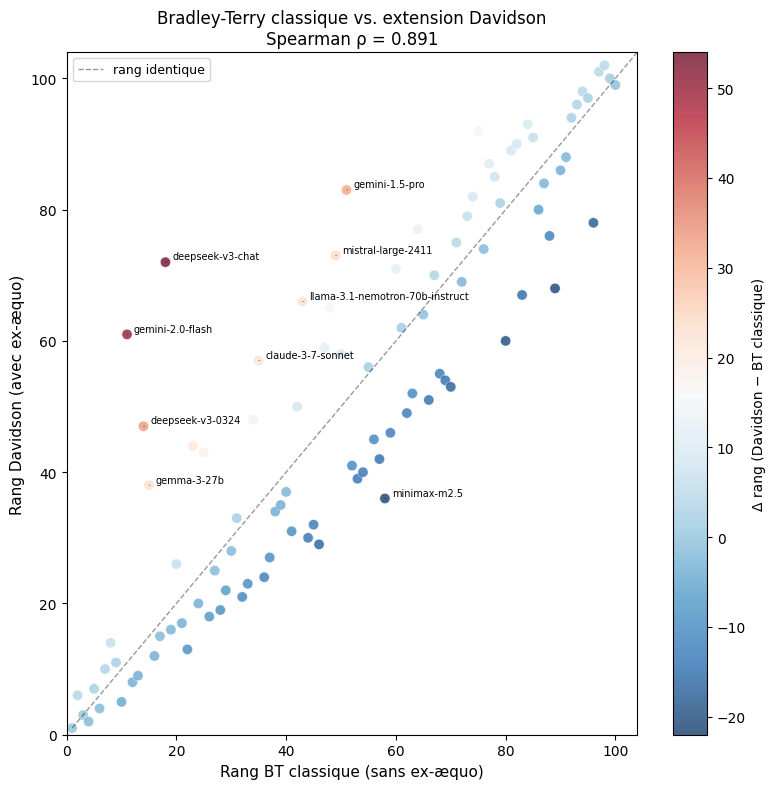


Modèles avec les plus grands écarts BT ↔ Davidson :


,model,rank_bt,rank_davidson,rank_diff
0,deepseek-v3-chat,18,72,54
1,gemini-2.0-flash,11,61,50
2,deepseek-v3-0324,14,47,33
3,gemini-1.5-pro,51,83,32
4,mistral-large-2411,49,73,24
5,llama-3.1-nemotron-70b-instruct,43,66,23
6,gemma-3-27b,15,38,23
7,claude-3-7-sonnet,35,57,22
8,minimax-m2.5,58,36,-22
9,gemma-3-12b,23,44,21


In [17]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ── Comparaison BT classique vs Davidson ────────────────────────────────────
# Joindre sur les modèles communs
df_bt_sub = df_rank_global[['model', 'rank']].rename(columns={'rank': 'rank_bt'})
df_cmp = df_bt_sub.merge(
    df_rank_davidson[['model', 'rank_davidson']],
    on='model'
)

rho_btd, pval_btd = spearmanr(df_cmp['rank_bt'], df_cmp['rank_davidson'])
print(f"Modèles communs BT / Davidson : {len(df_cmp)}")
print(f"Spearman ρ (BT vs Davidson)   : {rho_btd:.4f}  (p = {pval_btd:.2e})")

# ── Scatter plot ─────────────────────────────────────────────────────────────
df_cmp['rank_diff'] = df_cmp['rank_davidson'] - df_cmp['rank_bt']
df_cmp['abs_diff']  = df_cmp['rank_diff'].abs()
threshold_dav = df_cmp['abs_diff'].nlargest(8).min()

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(
    df_cmp['rank_bt'], df_cmp['rank_davidson'],
    c=df_cmp['rank_diff'], cmap='RdBu_r',
    s=55, alpha=0.75, edgecolors='white', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='Δ rang (Davidson − BT classique)')

lim = max(df_cmp[['rank_bt', 'rank_davidson']].max()) + 2
ax.plot([1, lim], [1, lim], 'k--', lw=1, alpha=0.4, label='rang identique')

for _, row in df_cmp[df_cmp['abs_diff'] >= threshold_dav].iterrows():
    ax.annotate(
        row['model'], xy=(row['rank_bt'], row['rank_davidson']),
        fontsize=7, xytext=(5, 2), textcoords='offset points',
        arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.5)
    )

ax.set_xlabel("Rang BT classique (sans ex-æquo)", fontsize=11)
ax.set_ylabel("Rang Davidson (avec ex-æquo)", fontsize=11)
ax.set_title(
    f"Bradley-Terry classique vs. extension Davidson\nSpearman ρ = {rho_btd:.3f}",
    fontsize=12
)
ax.legend(fontsize=9)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

print("\nModèles avec les plus grands écarts BT ↔ Davidson :")
display(
    df_cmp.sort_values('abs_diff', ascending=False)
          .head(12)[['model', 'rank_bt', 'rank_davidson', 'rank_diff']]
          .reset_index(drop=True)
)
